# Lazy cells: moving the baseline towards Kumar's regime

The two earlier notebooks found a short gap between the train and test crossings, a weight norm that grows eightfold, and a kernel whose scale grows by a factor of a few hundred. All three say the mean-field baseline is in the rich regime, where features move as soon as the loss does. Kumar et al. (2024) describe grokking as memorisation by a lazy network followed by slow feature learning, so a longer gap needs a lazier start.

Mean-field and NTK parameterisation differ only in the output scale, by a factor of the square root of the width. At width 100 that factor is ten, and it is the same knob as the proposal's alpha. So Kumar's alpha equal to 1 at learning rate 100 in NTK parameterisation is our mean-field cell at alpha 10 with base rate 10,000 and the rate divided by alpha squared. This notebook runs alpha 5, 10 and 20 at 100,000 steps, together with alpha 10 at initialisation scale 1.8 so the initial weight norm also matches the start of Kumar's Figure 2(a). The alpha 1 reference is seed 0 from `sam_early_tests.ipynb`, which ran for 50,000 steps.

Two comparisons are learning-rate free and are used throughout. The ratio of the test crossing to the train crossing does not change when the rate rescales time. The growth factor of the weight norm over the run can be read off Kumar's Figure 2(a), where the norm goes from about 150 to about 350.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import ntk_lib as L
from ntk_lib import (run_or_load, grokking_time, format_time, value_at_step, peak_step,
                     plot_series, log_step_axis, mark_crossings, BLUE, ORANGE, AQUA, GRAY, RAMP)

torch.set_num_threads(4)
L.set_plot_style()

ETA_0 = 10000.0
STEPS = 100000
TAU_TRAIN = 3e-3
TAU_TEST = 3e-3
RERUN = False

def gt(run):
    return grokking_time(run, TAU_TRAIN, TAU_TEST)

def first_step_at_least(run, key, level):
    """First recorded step at which the history value reaches level, or None."""
    h = run["history"]
    idx = np.where(np.asarray(h[key]) >= level)[0]
    return int(h["step"][idx[0]]) if len(idx) else None

## 1. Runs

In [2]:
ALPHAS = [1.0, 5.0, 10.0, 20.0]
runs = {1.0: run_or_load("early_seed0", rerun=RERUN, seed=0, eta_0=ETA_0, steps=50000, eval_interval=250)}
for a in ALPHAS[1:]:
    runs[a] = run_or_load(f"lazy_alpha{a:g}", rerun=RERUN, alpha=a, eta_0=ETA_0, steps=STEPS, eval_interval=500)
run_sigma = run_or_load("lazy_alpha10_sigma1.8", rerun=RERUN, alpha=10.0, init_scale=1.8, eta_0=ETA_0,
                        steps=STEPS, eval_interval=500)

cells_ = [(f"alpha {a:g}", runs[a]) for a in ALPHAS] + [("alpha 10, sigma 1.8", run_sigma)]
gs = {label: gt(r) for label, r in cells_}

print(f"{'cell':>20} {'t_train':>8} {'t_test':>8} {'ratio':>6} {'t_grok':>8} {'acc 0.95':>8} "
      f"{'norm 0':>7} {'norm end':>8} {'growth':>6} {'A@test':>7} {'A peak':>7} {'Rc@test':>7} {'Sc@test':>7} "
      f"{'test end':>9}")
for label, r in cells_:
    g = gs[label]
    h = r["history"]
    n0, n1 = r["init_weight_norm"], h["weight_norm"][-1]
    t_acc = first_step_at_least(r, "test_acc", 0.95)
    if g["t_test"] is None:
        print(f"{label:>20} {str(g['t_train']):>8} {'-':>8} {'-':>6} {format_time(g):>8} {str(t_acc):>8} "
              f"{n0:>7.0f} {n1:>8.0f} {n1 / n0:>6.2f} {'-':>7} {max(h['A_t']):>7.4f} {'-':>7} {'-':>7} "
              f"{h['test_loss'][-1]:>9.2e}")
        continue
    t = g["t_test"]
    print(f"{label:>20} {g['t_train']:>8} {t:>8} {t / g['t_train']:>6.2f} {g['t_grok']:>8} {str(t_acc):>8} "
          f"{n0:>7.0f} {n1:>8.0f} {n1 / n0:>6.2f} {value_at_step(r, 'A_t', t):>7.4f} {max(h['A_t']):>7.4f} "
          f"{value_at_step(r, 'R_c', t):>7.4f} {value_at_step(r, 'S_c', t):>+7.3f} {h['test_loss'][-1]:>9.2e}")
print()
print("ratio is the test crossing divided by the train crossing. acc 0.95 is the first step at which test accuracy reaches 0.95.")
print("growth is the final weight norm divided by the initial one. Kumar et al., Figure 2(a), show about 150 to 350, a factor near 2.3.")
print()
print("Crossings under two other definitions. Loss thresholds of 0.01 on both losses, and accuracy, where the train")
print("crossing is the first step at train accuracy 1 and the test crossing the first step at test accuracy 0.95.")
print(f"{'cell':>20} {'t_train .01':>11} {'t_test .01':>10} {'gap .01':>8} {'train acc 1':>11} {'test acc .95':>12} {'acc gap':>8} {'ratio':>6}")
for label, r in cells_:
    g = grokking_time(r, 1e-2, 1e-2)
    ta_tr = first_step_at_least(r, "train_acc", 1.0)
    ta_te = first_step_at_least(r, "test_acc", 0.95)
    acc_gap = "-" if ta_tr is None or ta_te is None else ta_te - ta_tr
    ratio = "-" if ta_tr in (None, 0) or ta_te is None else f"{ta_te / ta_tr:.2f}"
    print(f"{label:>20} {str(g['t_train']):>11} {str(g['t_test']):>10} {format_time(g):>8} {str(ta_tr):>11} {str(ta_te):>12} {str(acc_gap):>8} {ratio:>6}")

def accuracy_crossings(run):
    """Train crossing at train accuracy 1 and test crossing at test accuracy 0.95."""
    return dict(t_train=first_step_at_least(run, "train_acc", 1.0),
                t_test=first_step_at_least(run, "test_acc", 0.95))

acc_gs = {label: accuracy_crossings(r) for label, r in cells_}

early_seed0: loaded from results/early_seed0.json
lazy_alpha5: loaded from results/lazy_alpha5.json
lazy_alpha10: loaded from results/lazy_alpha10.json
lazy_alpha20: loaded from results/lazy_alpha20.json
lazy_alpha10_sigma1.8: loaded from results/lazy_alpha10_sigma1.8.json
                cell  t_train   t_test  ratio   t_grok acc 0.95  norm 0 norm end growth  A@test  A peak Rc@test Sc@test  test end
             alpha 1     5500    13000   2.36     7500     3750      83     1205  14.59  0.1275  0.1397  0.0798  +5.514  1.48e-03
             alpha 5    25000    69500   2.78    44500    17000      83      527   6.39  0.1259  0.1371  0.0791  +3.929  2.41e-03
            alpha 10    55500        -      -   >44500    37500      83      379   4.59       -  0.1328       -       -  6.29e-03
            alpha 20     None        -      -        -    83000      83      253   3.07       -  0.1281       -       -  2.28e-02
 alpha 10, sigma 1.8    77500        -      -   >22500    47000     149     

## 2. Loss, accuracy and weight norm across alpha

Every cell has both crossings under the accuracy definition, so those are the marks here. An open dot is the train crossing, the first step at train accuracy 1, and a filled dot is the test crossing, the first step at test accuracy 0.95. The step axis is linear because the lazy cells cross late in the run. The alpha 1 run stops at 50,000 steps.

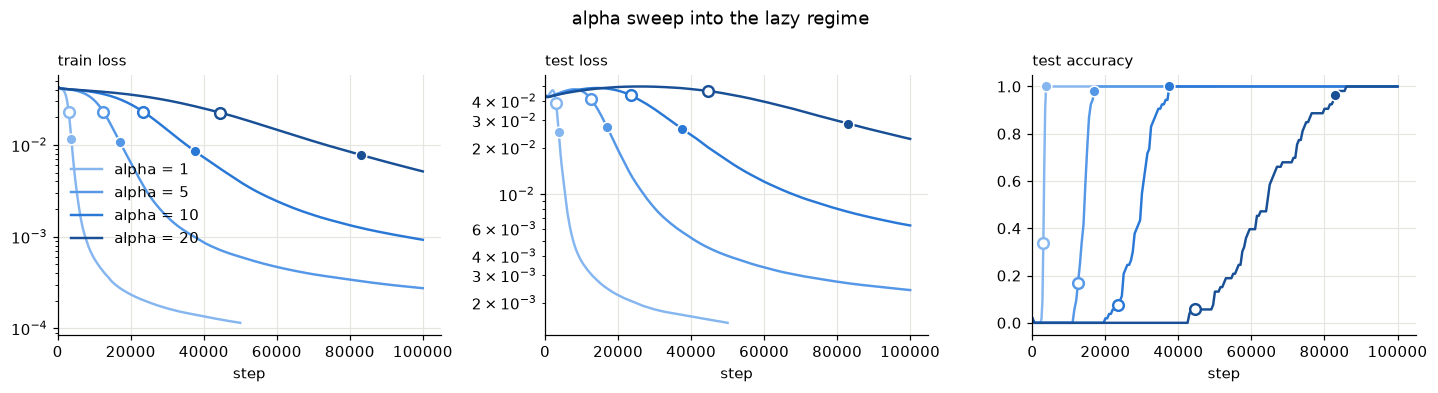

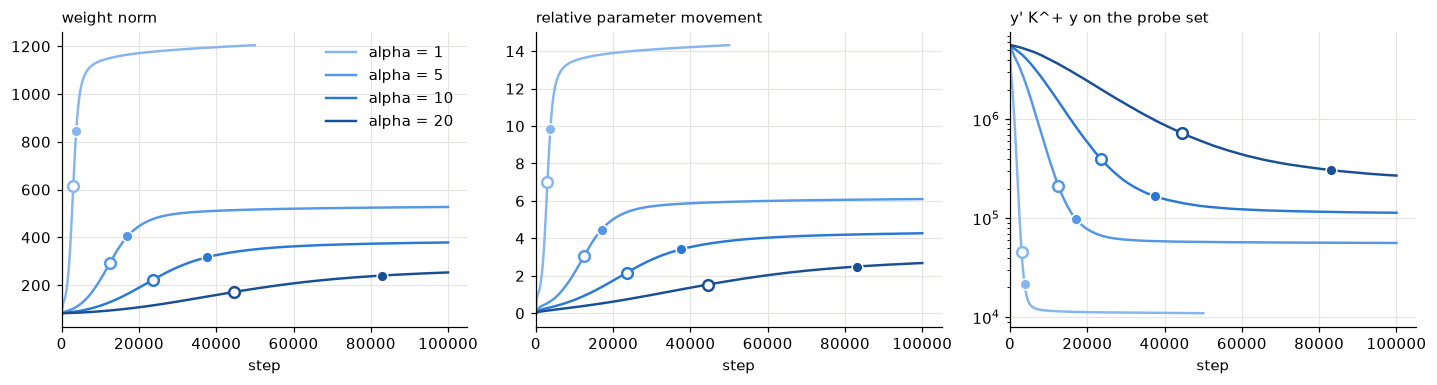

In [3]:
alpha_runs = [runs[a] for a in ALPHAS]
labels = [f"alpha = {a:g}" for a in ALPHAS]
crossings = [acc_gs[f"alpha {a:g}"] for a in ALPHAS]
fig = plot_series(alpha_runs, ["train_loss", "test_loss", "test_acc"], labels, RAMP,
                  ["train loss", "test loss", "test accuracy"],
                  log_y=("train_loss", "test_loss"), legend_panel=0, crossings=crossings, log_x=False, mark_train=True,
                  suptitle="alpha sweep into the lazy regime")
fig = plot_series(alpha_runs, ["weight_norm", "param_dist", "yKy"], labels, RAMP,
                  ["weight norm", "relative parameter movement", "y' K^+ y on the probe set"],
                  log_y=("yKy",), legend_panel=0, crossings=crossings, log_x=False, mark_train=True)

## 3. Kernel measures across alpha

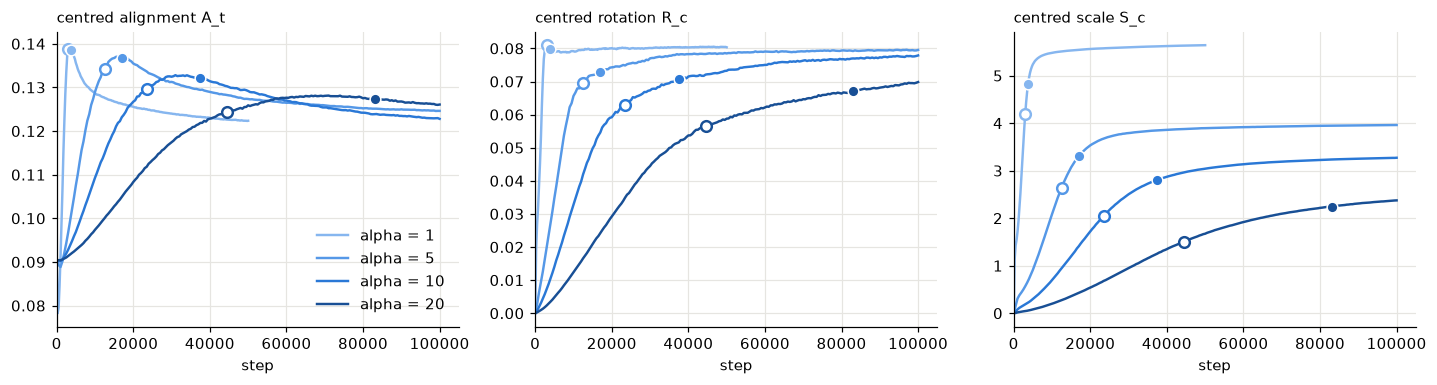

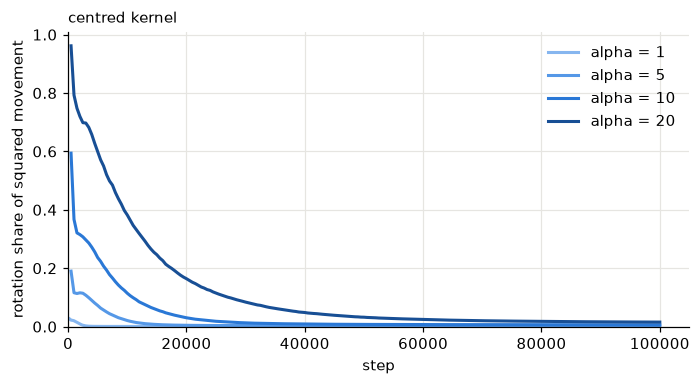

In [4]:
fig = plot_series(alpha_runs, ["A_t", "R_c", "S_c"], labels, RAMP,
                  ["centred alignment A_t", "centred rotation R_c", "centred scale S_c"],
                  legend_panel=0, crossings=crossings, log_x=False, mark_train=True)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for colour, a in zip(RAMP, ALPHAS):
    h = runs[a]["history"]
    S, R = np.asarray(h["S_c"]), np.asarray(h["R_c"])
    total = np.exp(2 * S) + 1 - 2 * np.exp(S) * (1 - R)
    share = np.where(total > 0, 2 * np.exp(S) * R / np.where(total > 0, total, 1), np.nan)
    ax.plot(h["step"], share, color=colour, label=f"alpha = {a:g}")
ax.set_ylim(0, None)
ax.set_xlabel("step")
ax.set_ylabel("rotation share of squared movement")
ax.set_title("centred kernel", loc="left", fontsize=10)
L.linear_step_axis(ax)
ax.legend()
fig.tight_layout()

## 4. Every grokking point on one plot

Each cell contributes two points: the train crossing and the test crossing under the accuracy definition. The vertical distance between them at a given alpha is the gap on a log scale, so parallel lines mean a constant ratio and diverging lines mean the ratio grows with alpha. The matched cell at sigma 1.8 is drawn in orange at alpha 10.

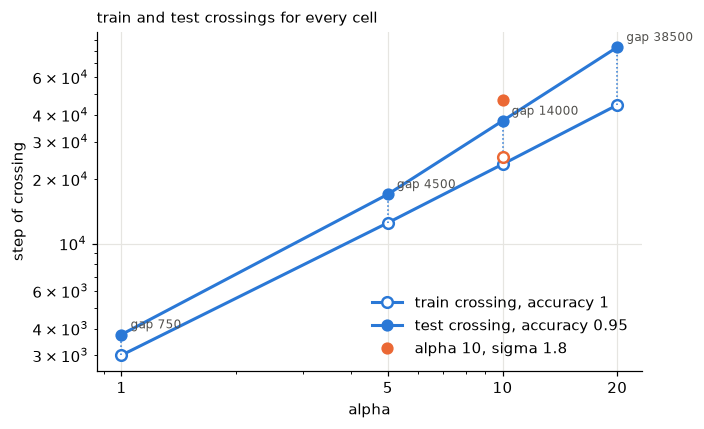

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
tr = [acc_gs[f"alpha {a:g}"]["t_train"] for a in ALPHAS]
te = [acc_gs[f"alpha {a:g}"]["t_test"] for a in ALPHAS]
ax.plot(ALPHAS, tr, "o-", color=BLUE, ms=7, markerfacecolor="white", markeredgewidth=1.6, label="train crossing, accuracy 1")
ax.plot(ALPHAS, te, "o-", color=BLUE, ms=7, label="test crossing, accuracy 0.95")
for a, t0, t1 in zip(ALPHAS, tr, te):
    ax.plot([a, a], [t0, t1], color=BLUE, lw=1, ls=":")
    ax.annotate(f"gap {t1 - t0}", (a, t1), textcoords="offset points", xytext=(6, 4), fontsize=8, color=GRAY)
gsig = acc_gs["alpha 10, sigma 1.8"]
ax.plot([10], [gsig["t_train"]], "o", color=ORANGE, ms=7, markerfacecolor="white", markeredgewidth=1.6)
ax.plot([10], [gsig["t_test"]], "o", color=ORANGE, ms=7, label="alpha 10, sigma 1.8")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(ALPHAS)
ax.set_xticklabels([f"{a:g}" for a in ALPHAS])
ax.set_xlabel("alpha")
ax.set_ylabel("step of crossing")
ax.set_title("train and test crossings for every cell", loc="left", fontsize=10)
ax.legend(loc="lower right")
fig.tight_layout()

## 5. Alpha 10 with the initial weight norm matched to Kumar's figure

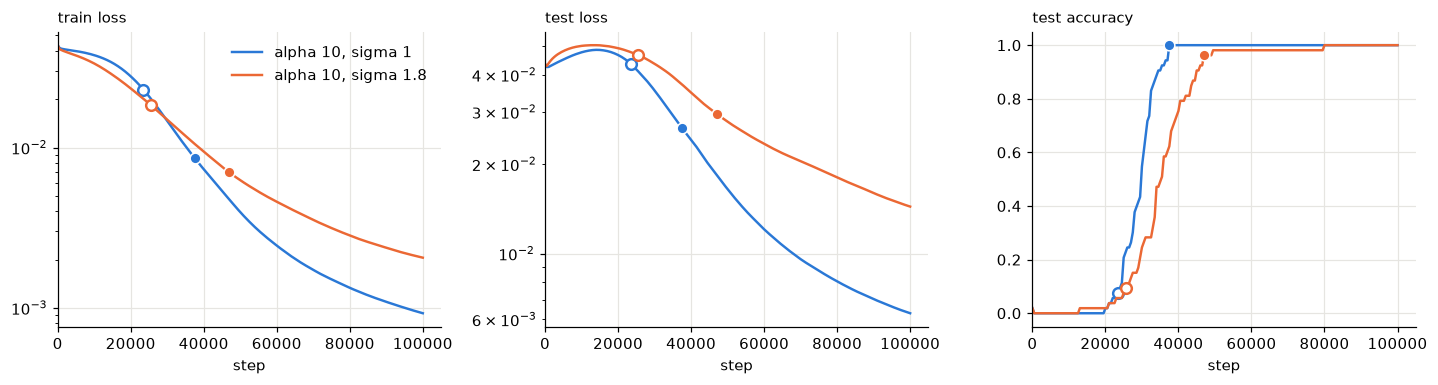

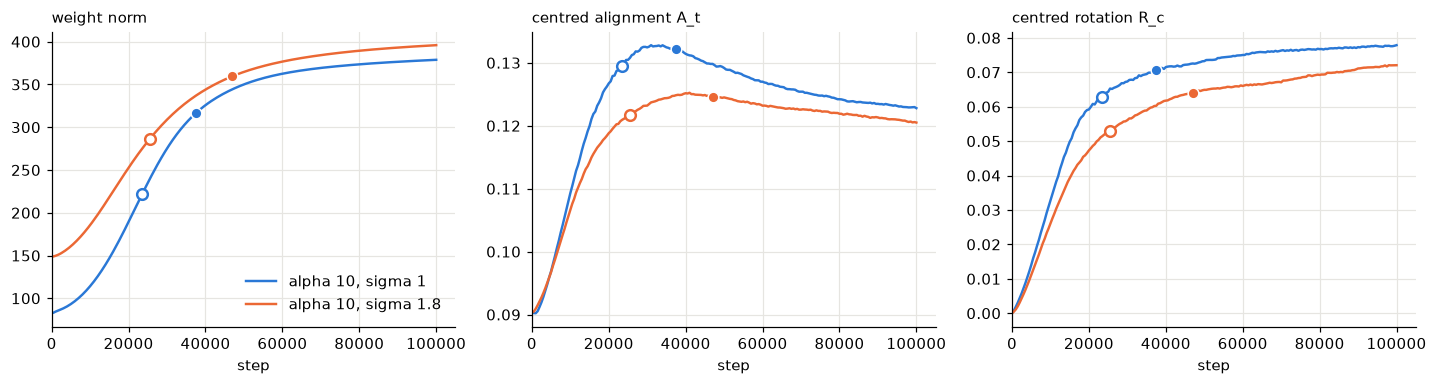

In [6]:
pair = [runs[10.0], run_sigma]
pair_labels = ["alpha 10, sigma 1", "alpha 10, sigma 1.8"]
pair_g = [acc_gs["alpha 10"], acc_gs["alpha 10, sigma 1.8"]]
fig = plot_series(pair, ["train_loss", "test_loss", "test_acc"], pair_labels, [BLUE, ORANGE],
                  ["train loss", "test loss", "test accuracy"],
                  log_y=("train_loss", "test_loss"), legend_panel=0, crossings=pair_g, log_x=False, mark_train=True)
fig = plot_series(pair, ["weight_norm", "A_t", "R_c"], pair_labels, [BLUE, ORANGE],
                  ["weight norm", "centred alignment A_t", "centred rotation R_c"],
                  legend_panel=0, crossings=pair_g, log_x=False, mark_train=True)

## 6. Five seeds of the matched cell

The matched cell is alpha 10 with sigma 1.8. Seed 0 is the run above and seeds 1 to 4 change the initialisation only. The crossings are the accuracy ones.

In [7]:
SEED_RUNS = [run_sigma] + [run_or_load(f"lazy_alpha10_sigma1.8_seed{s}", rerun=RERUN, seed=s, alpha=10.0, init_scale=1.8,
                                       eta_0=ETA_0, steps=STEPS, eval_interval=500) for s in (1, 2, 3, 4)]
seed_acc = [accuracy_crossings(r) for r in SEED_RUNS]

print(f"{'seed':>4} {'train acc 1':>11} {'test acc .95':>12} {'acc gap':>8} {'ratio':>6} {'norm end':>8} {'growth':>6} "
      f"{'A peak':>7} {'peak step':>9} {'A@test':>7} {'Rc@test':>7} {'Sc@test':>7} {'test loss end':>13}")
rows = []
for s_, r, g in zip(range(5), SEED_RUNS, seed_acc):
    h = r["history"]
    n0, n1 = r["init_weight_norm"], h["weight_norm"][-1]
    if g["t_train"] is None or g["t_test"] is None:
        print(f"{s_:>4} {str(g['t_train']):>11} {str(g['t_test']):>12}  no crossing")
        continue
    t = g["t_test"]
    row = dict(gap=g["t_test"] - g["t_train"], ratio=g["t_test"] / g["t_train"], growth=n1 / n0,
               A=value_at_step(r, "A_t", t), Apeak=max(h["A_t"]), Rc=value_at_step(r, "R_c", t), Sc=value_at_step(r, "S_c", t))
    rows.append(row)
    print(f"{s_:>4} {g['t_train']:>11} {t:>12} {row['gap']:>8} {row['ratio']:>6.2f} {n1:>8.0f} {row['growth']:>6.2f} "
          f"{row['Apeak']:>7.4f} {peak_step(r, 'A_t'):>9} {row['A']:>7.4f} {row['Rc']:>7.4f} {row['Sc']:>+7.3f} {h['test_loss'][-1]:>13.2e}")
for key, label in [("gap", "accuracy gap in steps"), ("ratio", "ratio of crossings"), ("growth", "weight norm growth"),
                   ("A", "alignment at test crossing"), ("Apeak", "alignment peak"), ("Rc", "centred rotation at test crossing")]:
    vals = np.array([row[key] for row in rows])
    print(f"{label}: mean {vals.mean():.4g}, standard deviation {vals.std(ddof=1):.3g}, n = {len(vals)}")

lazy_alpha10_sigma1.8_seed1: loaded from results/lazy_alpha10_sigma1.8_seed1.json
lazy_alpha10_sigma1.8_seed2: loaded from results/lazy_alpha10_sigma1.8_seed2.json
lazy_alpha10_sigma1.8_seed3: loaded from results/lazy_alpha10_sigma1.8_seed3.json
lazy_alpha10_sigma1.8_seed4: loaded from results/lazy_alpha10_sigma1.8_seed4.json
seed train acc 1 test acc .95  acc gap  ratio norm end growth  A peak peak step  A@test Rc@test Sc@test test loss end
   0       25500        47000    21500   1.84      396   2.66  0.1252     41000  0.1246  0.0640  +1.875      1.44e-02
   1       26000        66000    40000   2.54      398   2.64  0.1193     89500  0.1184  0.0665  +1.999      1.85e-02
   2       26500        59000    32500   2.23      395   2.68  0.1204     44000  0.1193  0.0691  +1.971      1.51e-02
   3       26500        50000    23500   1.89      395   2.64  0.1236     44500  0.1233  0.0624  +1.886      1.48e-02
   4       23500        73500    50000   3.13      400   2.69  0.1223     37000  0

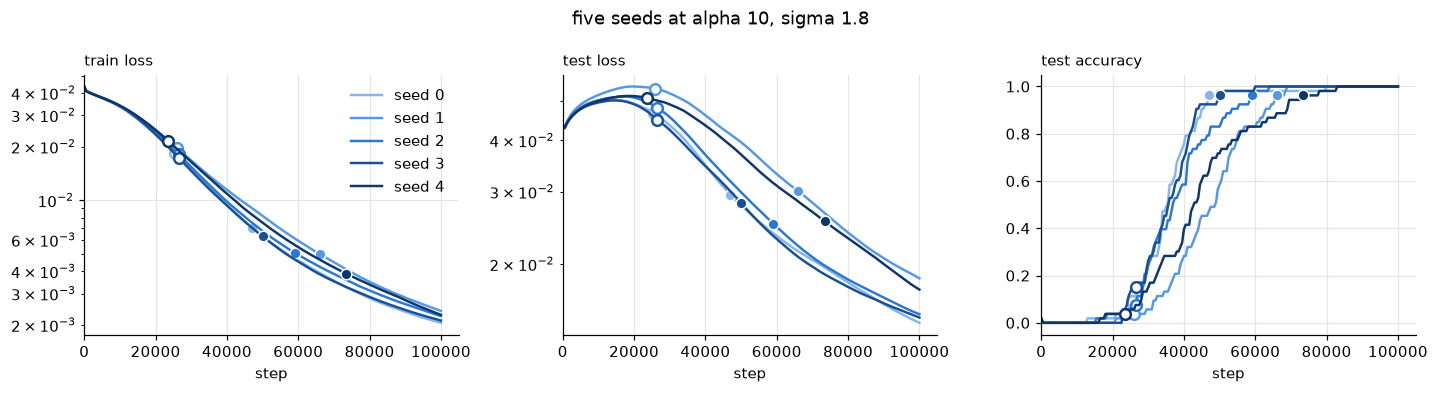

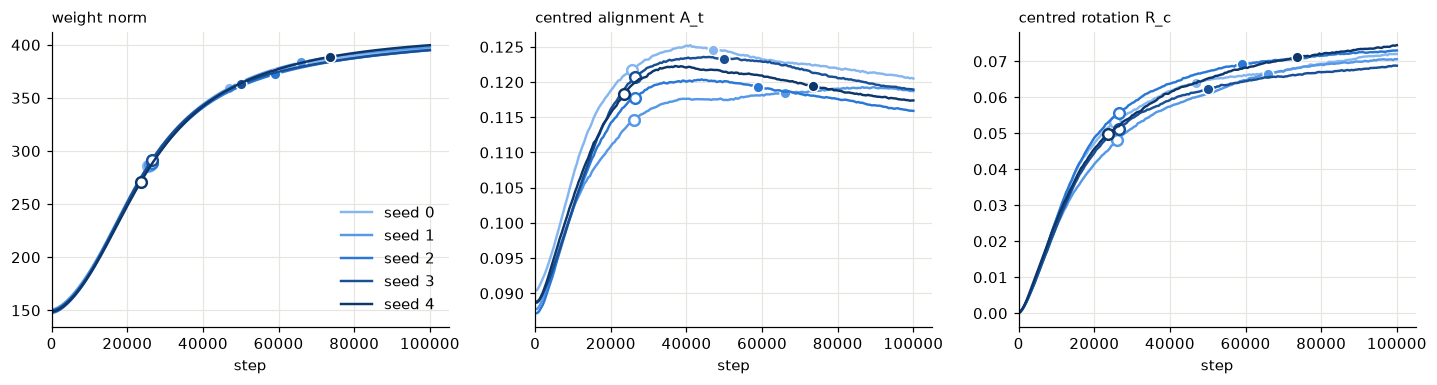

In [8]:
seed_labels = [f"seed {s_}" for s_ in range(5)]
fig = plot_series(SEED_RUNS, ["train_loss", "test_loss", "test_acc"], seed_labels, RAMP,
                  ["train loss", "test loss", "test accuracy"], log_y=("train_loss", "test_loss"),
                  legend_panel=0, crossings=seed_acc, log_x=False, mark_train=True,
                  suptitle="five seeds at alpha 10, sigma 1.8")
fig = plot_series(SEED_RUNS, ["weight_norm", "A_t", "R_c"], seed_labels, RAMP,
                  ["weight norm", "centred alignment A_t", "centred rotation R_c"],
                  legend_panel=0, crossings=seed_acc, log_x=False, mark_train=True)

## 7. Reading the results

These are the results of the run on 18 September 2026. The numbers are in the tables above.

**The gap lengthens as the network gets lazier, and the matched cell looks like Kumar's figure.** At alpha 1 the test accuracy reaches 0.95 at step 3,750. At alpha 5 it does so at 17,000, at alpha 10 at 37,500, and at alpha 20 at 83,000. The weight norm growth falls from a factor of 14.6 at alpha 1 to 3.1 at alpha 20. At alpha 10 with sigma 1.8 the norm goes from 149 to 396, a factor of 2.7, against about 150 to 350 in Kumar et al., Figure 2(a). That cell has learning rate 100 after the division by alpha squared, so its steps are their epochs at the same rate, and its test accuracy rises between steps 20,000 and 50,000, which is where their test accuracy rises. This is the closest match to the published figure so far and the candidate for the Tier 0 baseline. Stated plainly, it is mean-field parameterisation with ReLU and no biases, or equivalently NTK parameterisation, with weights of standard deviation 1.8, alpha 10 on the centred predictor, and learning rate 100.

**The loss thresholds do not work in the lazy cells.** At alpha 10 and above the test loss does not reach 0.003 within 100,000 steps even though test accuracy is one, and at alpha 20 the train loss does not reach it either. The loss falls slowly once accuracy is perfect because the outputs are still far from the one-hot targets. Loss thresholds of 0.01, about a quarter of chance, still censor the test crossing at alpha 20 and in the matched cell within 100,000 steps. Under the accuracy definition every cell has both crossings, and the ratio of the test crossing to the train crossing grows steadily with alpha, from 1.25 at alpha 1 to 1.87 at alpha 20. The group has to choose the definition before the sweeps. Longer runs with loss thresholds near 0.01, or accuracy crossings as the primary definition with loss crossings as the robustness check, are the two options that fit what was seen here. Whatever is chosen, the sensitivity should be reported as the proposal says.

**Rotation comes first in the lazy cells.** In the rich cell rotation was never more than a few percent of the squared kernel movement. At alpha 10 and 20 rotation is most of the movement for the first few thousand steps, and only later does scale growth take over and drive the share to zero. The centred rotation term still ends near 0.07 to 0.08 in every cell, and the alignment still peaks between 0.125 and 0.137 across alpha. So the kernel turns by about the same amount and reaches about the same alignment whether the network is rich or lazy, but in a lazy network the turning happens before the scale grows rather than alongside it. That is a cleaner setting for the proposal's question than the rich cell.

**Seeds.** Over five seeds of the matched cell the weight norm growth is 2.66 with a standard deviation of 0.02, so the match to Kumar's figure does not depend on the seed. The accuracy gap runs from 21,500 to 50,000 steps, with a mean of 33,500 and a standard deviation of 11,800. That is a spread of thirty five percent, against seventeen percent in the rich cell, so the lazy cell needs more seeds per cell than the rich one to pin the grokking time down, and the proposal's five seeds per cell may be too few there. The ratio of the crossings runs from 1.8 to 3.1. The alignment at the test crossing is 0.121 with a standard deviation of 0.003 and the alignment peak is 0.122 with a standard deviation of 0.002, so in the lazy cell the test crossing sits at the peak rather than on the decline. The rich cell gave 0.126 at the crossing. The two levels are within four percent of each other but the difference is larger than the seed spread, so whether the threshold is shared across alpha is still open and needs the full grid. The centred rotation at the crossing is 0.067 with a standard deviation of 0.004, below the 0.079 of the rich cell.

**Next.** After that, the alpha grid for Tier 1 should be log-spaced around alpha 10, and the one-cell weight-decay test should run at the matched cell.